In [1]:
!pwd

/truejit/evaluation/smartjit


In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Palatino"],
})

In [3]:
import subprocess
from pathlib import Path
from Benchmarking import TrueJIT
import time
import json
import matplotlib.pyplot as plt
import uuid

In [4]:
from mibench.suite import mibench
from spec.suite import spec
from coremark.benchmark import coremark
from ffmpeg.benchmark import ffmpeg
from sqlite.benchmark import sqlite
from jetstream.suite import jetstream
from polybench.suite import suite as polybench
from npb.suite import suite as npb
from wabench.suite import wabench

all_benchmarks = []
all_benchmarks.extend(jetstream.benchmarks)
all_benchmarks.extend([coremark])
all_benchmarks.extend([sqlite])
all_benchmarks.extend(mibench.benchmarks)
all_benchmarks.extend(spec.benchmarks)
all_benchmarks.extend(npb('S').benchmarks)
all_benchmarks.extend(wabench.benchmarks)
all_benchmarks.extend(polybench('extra-large').benchmarks)
all_benchmarks.extend([ffmpeg])

In [5]:
def get_num_functions(benchmark):
    out = subprocess.run(['wasm-objdump', '-h', benchmark.binary], text=True, check=True, capture_output=True)
    out = out.stdout.split('\n')
    for line in out:
        if 'Function' in line:
            num_funcs = line.split(' ')[-1]
            return int(num_funcs)

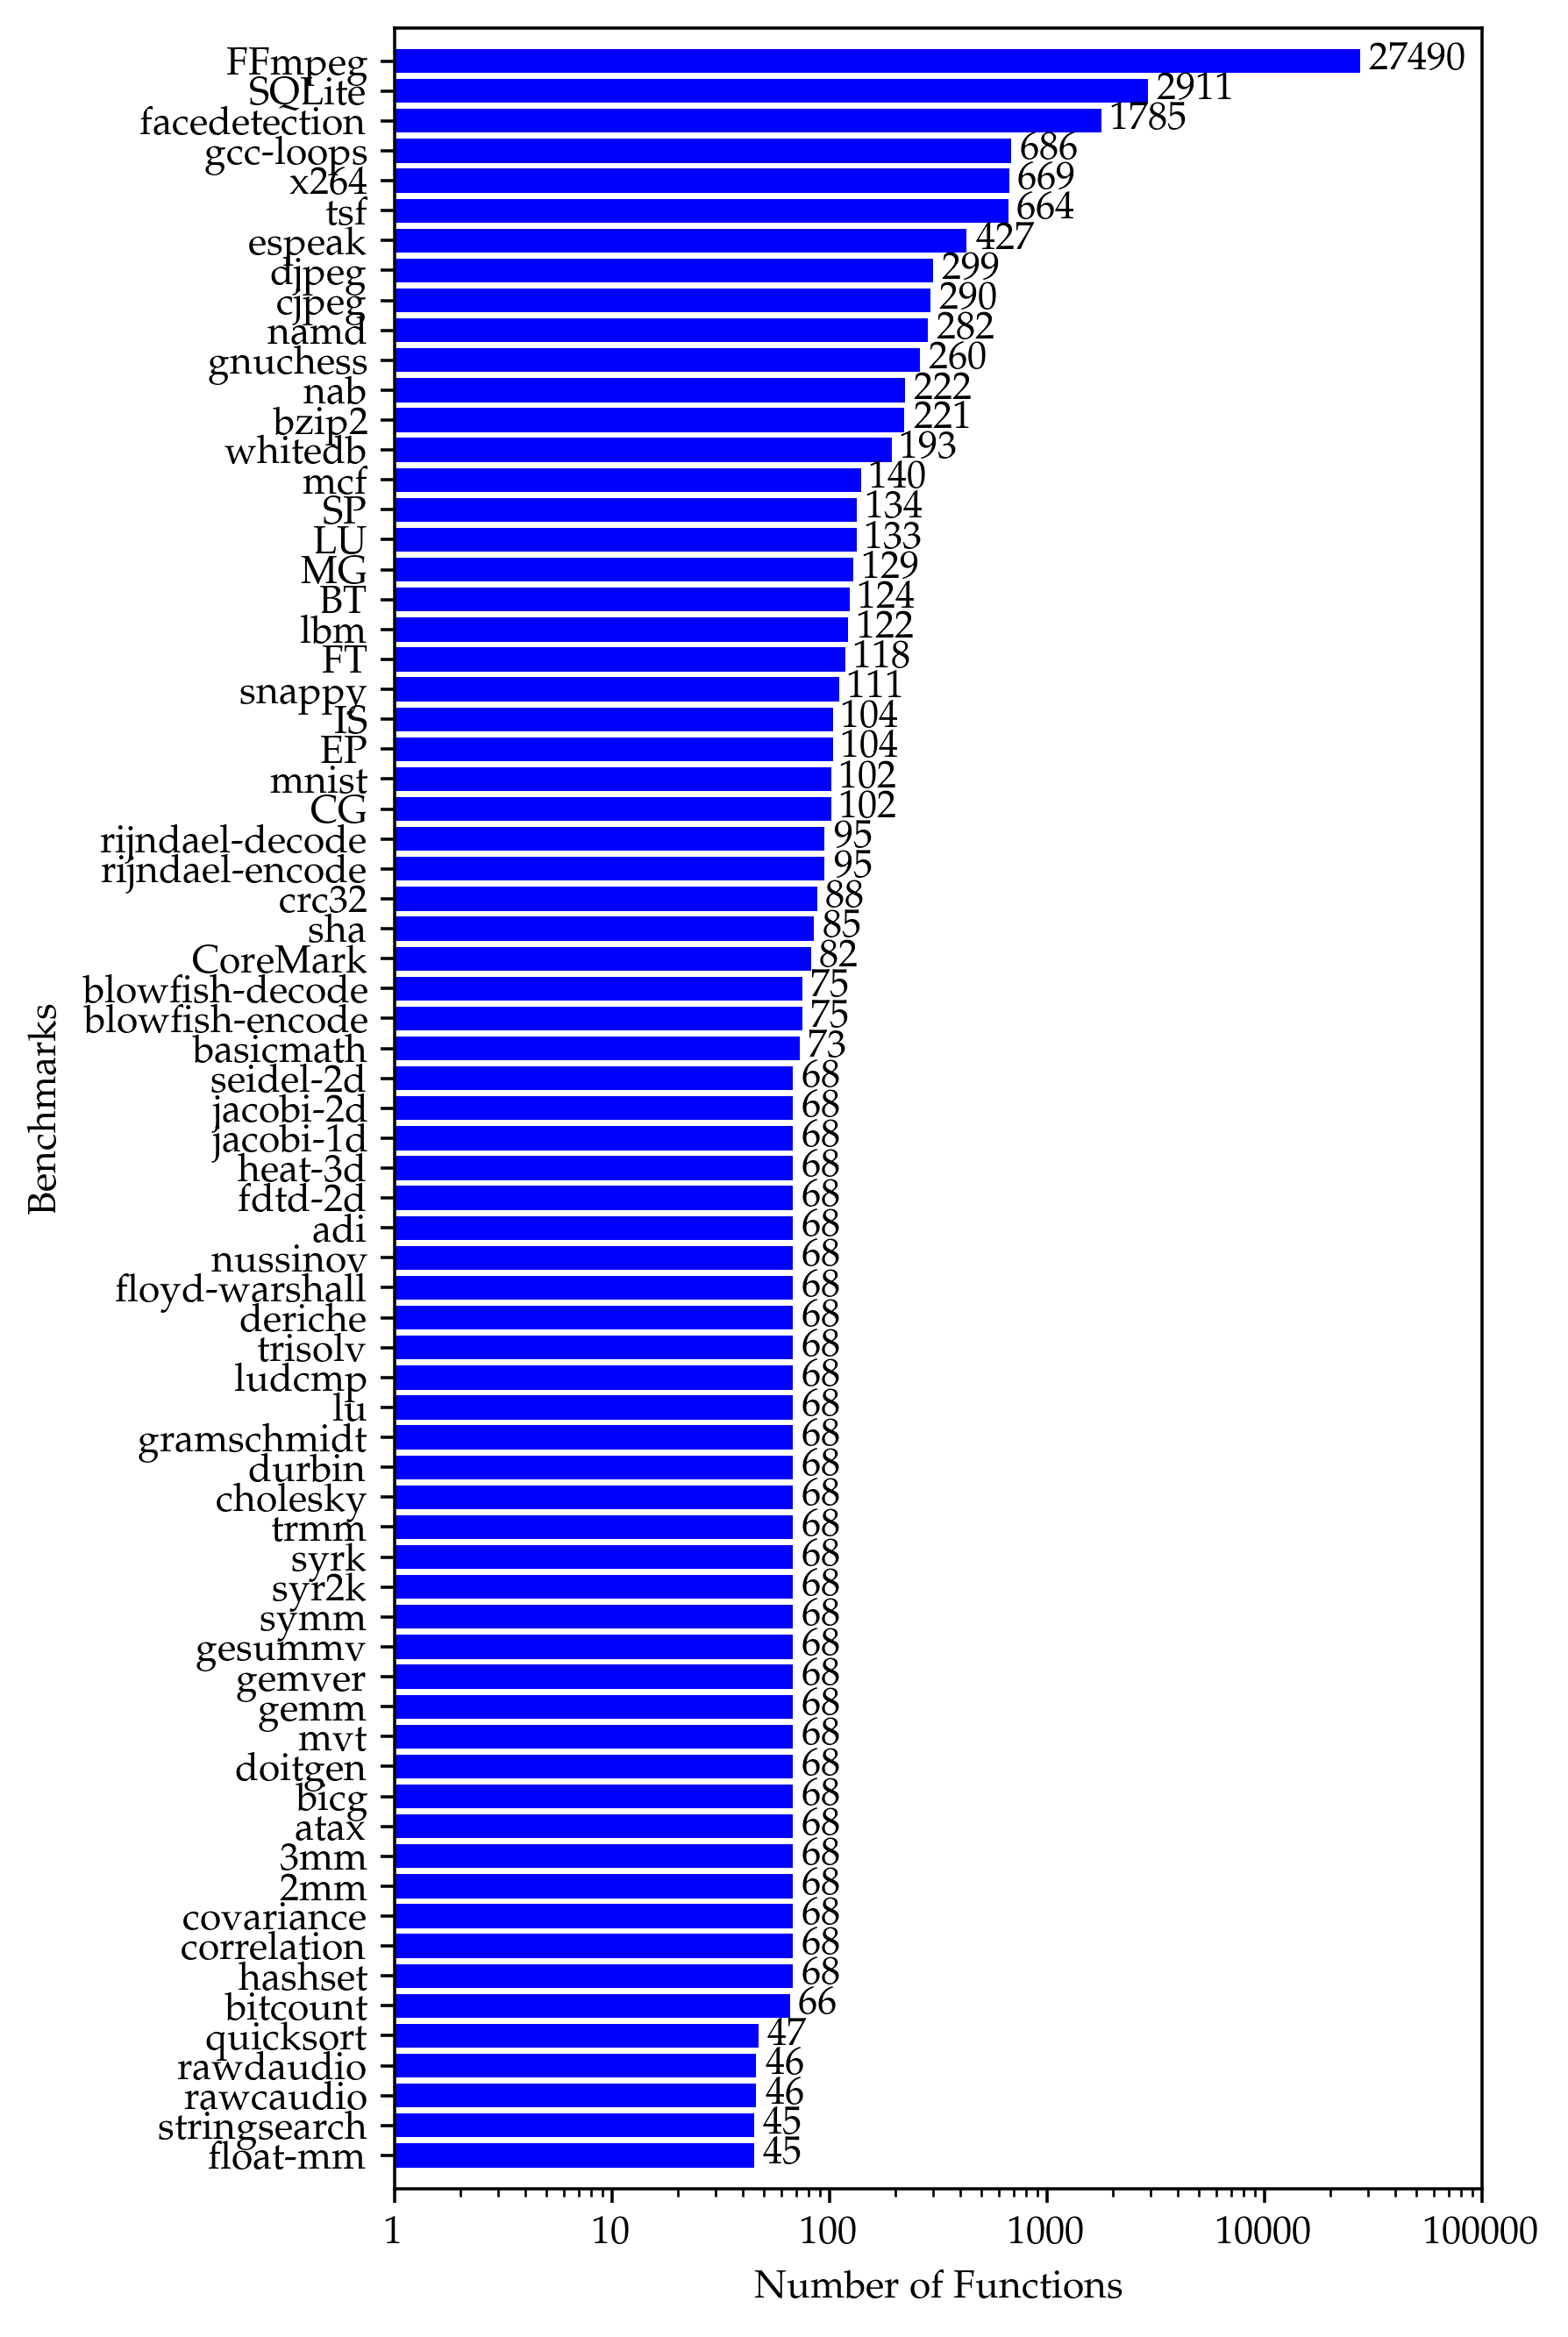

In [9]:
data = []
for benchmark in all_benchmarks:
    num_funcs = get_num_functions(benchmark)
    data.append((benchmark.mode, num_funcs))

# sort by the number of functions
data = sorted(data, key=lambda x: int(x[1]), reverse=False)

fig, ax = plt.subplots(figsize=(5, 10), dpi=320)

names = [d[0] for d in data]
funcs = [int(d[1]) for d in data]

ax.barh(names, funcs, color='blue')

for i, v in enumerate(funcs):
    ax.text(v * 1.1, i, str(v), color='black', va='center')

plt.margins(0.01)

ax.set_xscale('log')
ax.set_xticks([1, 10, 100, 1000, 10000, 100000])
# don't use scientific notation
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_ylabel('Benchmarks')
ax.set_xlabel('Number of Functions')

plt.show()

In [1]:
# import functions from the timeline.ipynb
%run timeline.ipynb

/truejit/evaluation/smartjit
benchmark=BT
scheme=[]


KeyboardInterrupt: 

KeyboardInterrupt: 

In [65]:
SUITES_NAMES = {'npb': 'NPB', 'polybench': 'Polybench', 'mibench': 'MiBench', 'wabench': 'WABench', 'spec': 'SPEC',
                'jetstream': 'JetStream', 'coremark': 'CoreMark', 'geomean': 'Geomean'}


def get_suites():
    suites = [
        {'name': 'polybench',
         'benchmarks': ['2mm', '3mm', 'adi', 'atax', 'bicg', 'cholesky', 'correlation', 'covariance', 'deriche',
                        'doitgen',
                        'durbin', 'fdtd-2d', 'floyd-warshall', 'gemm', 'gemver', 'gesummv', 'gramschmidt', 'heat-3d',
                        'jacobi-1d', 'jacobi-2d', 'lu', 'ludcmp', 'mvt', 'nussinov', 'seidel-2d', 'symm', 'syr2k',
                        'syrk',
                        'trisolv', 'trmm']},
        {'name': 'mibench',
         'benchmarks': ['basicmath', 'bitcount', 'cjpeg', 'djpeg', 'stringsearch', 'blowfish-decode', 'blowfish-encode',
                        'rijndael-decode', 'rijndael-encode', 'sha', 'rawcaudio', 'rawdaudio', 'crc32']},
        {'name': 'wabench',
         'benchmarks': ['bzip2', 'facedetection', 'gnuchess', 'espeak', 'mnist', 'snappy', 'whitedb']},
        {'name': 'spec',
         'benchmarks': ['lbm', 'mcf', 'x264',
                        'nab', 'namd'
                        ]},
        {'name': 'jetstream',
         'benchmarks': ['gcc-loops', 'float-mm', 'HashSet', 'quicksort', 'tsf']},
        {'name': 'npb',
         'benchmarks': ['bt', 'cg', 'ep', 'ft', 'is',
                        'lu',
                        'mg', 'sp']},
        {'name': 'coremark',
         'benchmarks': ['coremark']},
        {'name': 'geomean',
         'benchmarks': ['Geom.\nMean']},
    ]
    o = {}
    for s, suite in enumerate(suites):
        o[suite['name']] = {benchmark: {} for benchmark in suite['benchmarks']}
    return o


In [67]:
import scipy

csv = """
polybench:2mm, 1445, 934, 413, 120, 
polybench:3mm, 1265, 983, 454, 103, 
polybench:adi, 1292, 1022, 442, 150, 
polybench:atax, 1210, 799, 868, 813, 
polybench:bicg, 1166, 813, 986, 824, 
polybench:cholesky, 1257, 993, 484, 90, 
polybench:correlation, 1242, 1042, 448, 135, 
polybench:covariance, 1218, 997, 511, 126, 
polybench:deriche, 1325, 1023, 446, 148, 
polybench:doitgen, 1330, 1143, 494, 148, 
polybench:durbin, 1121, 805, 1135, 896, 
polybench:fdtd-2d, 1316, 970, 448, 103, 
polybench:floyd-warshall, 1336, 1051, 497, 100, 
polybench:gemm, 1303, 1014, 459, 123, 
polybench:gemver, 1119, 936, 1011, 728, 
polybench:gesummv, 1204, 817, 1096, 705, 
polybench:gramschmidt, 1276, 961, 438, 117, 
polybench:heat-3d, 1295, 932, 444, 133, 
polybench:jacobi-1d, 978, 889, 1204, 853, 
polybench:jacobi-2d, 1355, 955, 417, 114, 
polybench:lu, 1436, 1051, 516, 100, 
polybench:ludcmp, 1415, 957, 472, 88, 
polybench:mvt, 1121, 837, 883, 644, 
polybench:nussinov, 1432, 1004, 520, 134, 
polybench:seidel-2d, 1268, 995, 418, 114, 
polybench:symm, 1504, 973, 450, 128, 
polybench:syr2k, 1342, 920, 482, 124, 
polybench:syrk, 1322, 976, 382, 130, 
polybench:trisolv, 1151, 849, 1121, 801, 
polybench:trmm, 1310, 1084, 512, 138, 
jetstream:gcc-loops, 2828, 2348, 1278, 791, 
jetstream:float-mm, 719, 204, 705, 164, 
jetstream:HashSet, 8681, 8661, 8267, 8697, 
jetstream:quicksort, 696, 725, 683, 681, 
jetstream:tsf, 8461, 6866, 8135, 6264,                                          
mibench:basicmath, 1290, 570, 1193, 450, 
mibench:bitcount, 1292, 849, 1015, 818, 
mibench:cjpeg, 2882, 2159, 3154, 2059, 
mibench:djpeg, 2968, 2502, 3036, 2433, 
mibench:stringsearch, 849, 840, 761, 714, 
mibench:blowfish-decode, 821, 473, 981, 446, 
mibench:blowfish-encode, 951, 479, 1015, 414, 
mibench:rijndael-decode, 1027, 563, 1074, 455, 
mibench:rijndael-encode, 993, 591, 994, 491, 
mibench:sha, 1524, 965, 1491, 994, 
mibench:rawcaudio, 755, 774, 461, 434, 
mibench:rawdaudio, 772, 796, 573, 484, 
mibench:crc32, 1317, 909, 1245, 671, 
wabench:bzip2, 3891, 3191, 3661, 2845, 
wabench:espeak, 5199, 3675, 4898, 3462, 
wabench:facedetection, 5529, 4719, 5071, 3909, 
wabench:gnuchess, 3969, 2818, 3737, 2972, 
wabench:mnist, 1520, 1021, 1420, 653, 
wabench:snappy, 1857, 1424, 356, 2, 
wabench:whitedb, 2998, 1598, 825, 6, 
npb:bt, 3344, 2400, 3463, 2594, 
npb:cg, 1551, 895, 1492, 923, 
npb:ep, 1414, 964, 1061, 864, 
npb:ft, 1865, 1464, 1881, 1241, 
npb:is, 1366, 927, 1502, 1092, 
npb:lu, 3010, 2669, 3092, 2430, 
npb:mg, 2080, 1596, 2293, 1458, 
npb:sp, 3045, 2701, 2923, 2424, 
coremark:coremark, 1810, 1273, 875, 376, 
spec:lbm, 1555, 1039, 1190, 716, 
spec:mcf, 2187, 1699, 1927, 1427, 
spec:x264, 14123, 12249, 12490, 9949, 
spec:nab, 4215, 3117, 4138, 3208, 
spec:namd, 10939, 10852, 2788, 1884,
"""

lines = csv.strip().split('\n')
lines = [line.split(',') for line in lines]
lines = [(line[0], float(line[1]), float(line[2]), float(line[3]), float(line[4])) for line in lines]
# line[0] is {suite}:{benchmark}
lines = [(line[0].split(':')[0], line[0].split(':')[1], [line[1], line[2], line[3], line[4]]) for line in lines]

# schemes = ['jit', 'jit.startup-static-code-cache', 'jit.oracle-async-compilation',
#            'jit.oracle-async-compilation.startup-static-code-cache']
schemes = ['JIT', 'JIT+StaticCodeCache', 'JIT+AsyncCompilation', 'JIT+AsyncCompilation+StaticCodeCache']

suites = get_suites()

for suite, benchmark, vals in lines:
    baseline = vals[0]
    vals = [baseline / v for v in vals]
    for s, scheme in enumerate(schemes):
        suites[suite][benchmark][scheme] = vals[s]

for scheme in schemes:
    latencies = []
    for suite in suites.values():
        # print(f"suite: {suite}")
        for benchmark in suite:
            # print(f"benchmark: {benchmark}")
            if benchmark != 'Geom.\nMean':
                latencies.append(suite[benchmark][scheme])
    geomean = scipy.stats.mstats.gmean(latencies)
    suites['geomean']['Geom.\nMean'][scheme] = geomean

suites

{'polybench': {'2mm': {'JIT': 1.0,
   'JIT+StaticCodeCache': 1.5471092077087794,
   'JIT+AsyncCompilation': 3.4987893462469732,
   'JIT+AsyncCompilation+StaticCodeCache': 12.041666666666666},
  '3mm': {'JIT': 1.0,
   'JIT+StaticCodeCache': 1.2868769074262463,
   'JIT+AsyncCompilation': 2.7863436123348015,
   'JIT+AsyncCompilation+StaticCodeCache': 12.281553398058252},
  'adi': {'JIT': 1.0,
   'JIT+StaticCodeCache': 1.264187866927593,
   'JIT+AsyncCompilation': 2.923076923076923,
   'JIT+AsyncCompilation+StaticCodeCache': 8.613333333333333},
  'atax': {'JIT': 1.0,
   'JIT+StaticCodeCache': 1.5143929912390488,
   'JIT+AsyncCompilation': 1.3940092165898617,
   'JIT+AsyncCompilation+StaticCodeCache': 1.4883148831488315},
  'bicg': {'JIT': 1.0,
   'JIT+StaticCodeCache': 1.4341943419434193,
   'JIT+AsyncCompilation': 1.182555780933063,
   'JIT+AsyncCompilation+StaticCodeCache': 1.4150485436893203},
  'cholesky': {'JIT': 1.0,
   'JIT+StaticCodeCache': 1.2658610271903323,
   'JIT+AsyncCompilat

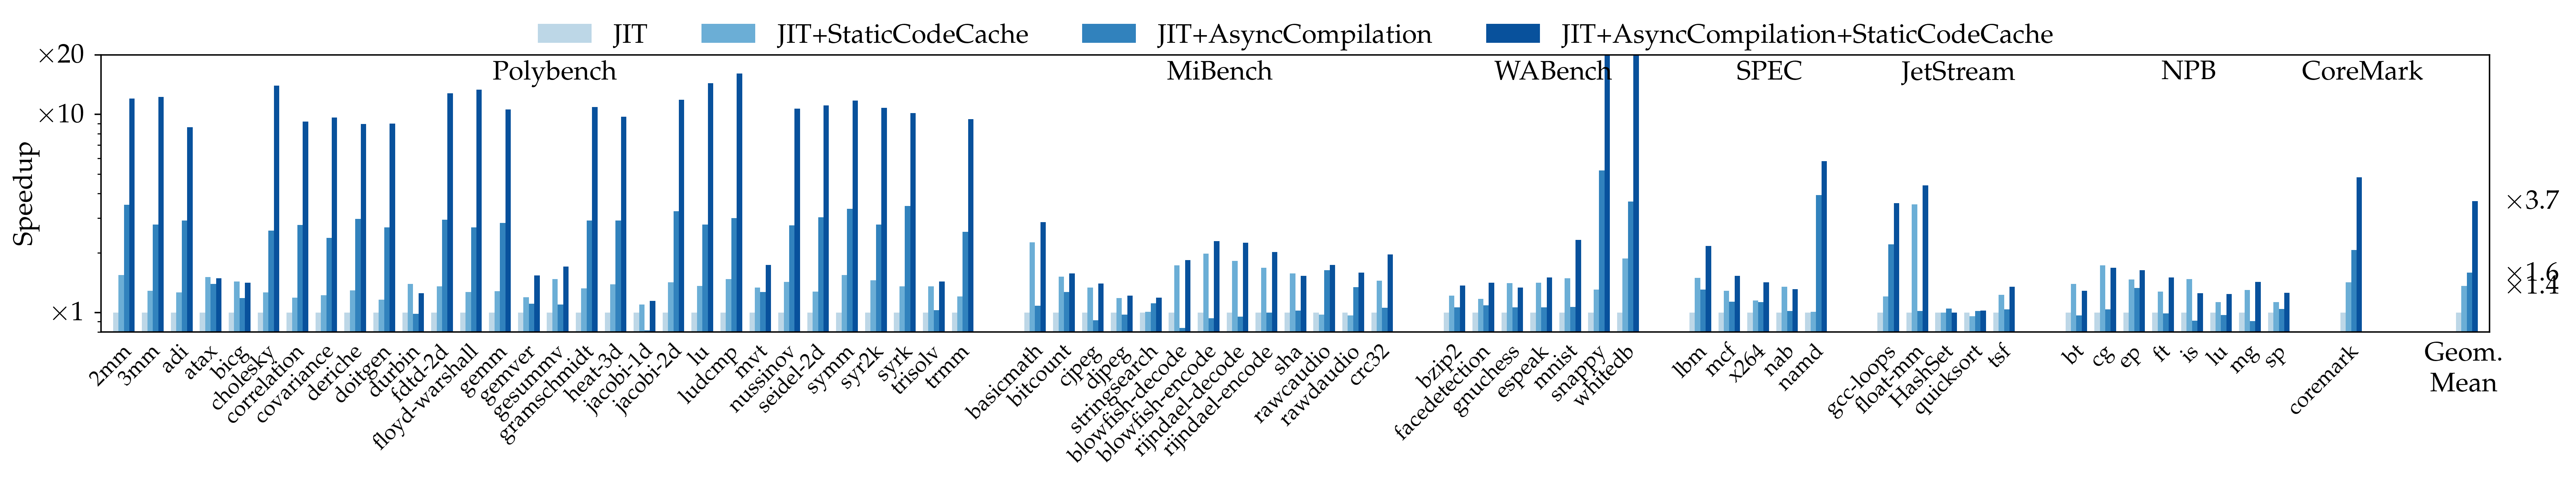

In [68]:
import matplotlib.pyplot as plt
import bokeh.palettes

# colors
colors = bokeh.palettes.Blues[len(schemes) + 1][:-1]
colors = colors[::-1]

# bars and spaces
bar_width = .75
scheme_bar_width = bar_width / len(schemes)
SPACE_BETWEEN_SUITES = 1.5

# figure
width = 20
height = 4
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# plot bars
suite_x = 0
xs = []
for name, suite in suites.items():
    if name == 'geomean':
        suite_x += SPACE_BETWEEN_SUITES
    suite_x_start = suite_x
    for b, key in enumerate(suite.keys()):
        benchmark = suite[key]
        xs.append((suite_x + b, key))
        for s, scheme in enumerate(schemes):
            x = suite_x + b + (s - 1) * scheme_bar_width
            value = benchmark[scheme]
            color = colors[s]
            ax.bar(x, value, width=scheme_bar_width, color=color, edgecolor='none', linewidth=0.25)
    # write suite name on top middle of group of bars
    if name not in ['geomean']:
        x = suite_x_start + len(suite) / 2
        y = 16
        ax.text(x, y, SUITES_NAMES[name], ha='center', va='center', fontsize=15)
    suite_x += len(suite) + SPACE_BETWEEN_SUITES

# text on top of the geomean bar
for s, scheme in enumerate(schemes[1:]):
    x = suite_x - 1
    geomean = suites['geomean']['Geom.\nMean'][scheme]
    ax.text(x, geomean, f'$\\times{geomean:.1f}$', ha='left', va='center', fontsize=15)

# x-axis
x_ticks, x_labels = zip(*xs)
ax.set_xticks(x_ticks, x_labels, rotation=45, fontsize=12, ha='right', rotation_mode='anchor', va='top', y=0.01)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # no ticks

geomean_label = ax.get_xticklabels()[-1]
geomean_label.set_fontsize(15)
geomean_label.set_rotation(0)
geomean_label.set_ha('center')

# y-axis
ax.set_yscale('log')
ax.set_ylim((.8, 20))
y_ticks = [1, 10, 20]
y_labels = [f'$\\times{y}$' for y in y_ticks]
ax.set_yticks(y_ticks, y_labels, fontsize=15, ha='right', rotation_mode='anchor', va='center', y=0.1)
ax.set_ylabel('Speedup', fontsize=15, labelpad=0)

# margins
plt.margins(x=0.005, y=0)

# legend
legend = ax.legend(schemes,
                   loc='upper center',
                   bbox_to_anchor=(0.5, 1.2),
                   ncol=len(schemes),
                   fontsize=15,
                   frameon=False,
                   edgecolor='black')

# layout
plt.tight_layout()

# save (as pdf)
plt.savefig('out/waiting-time-speedup.static-code-cache-and-async-compilation.pdf', bbox_inches='tight',
            pad_inches=0.01, dpi=320, transparent=True)

# show
plt.show()

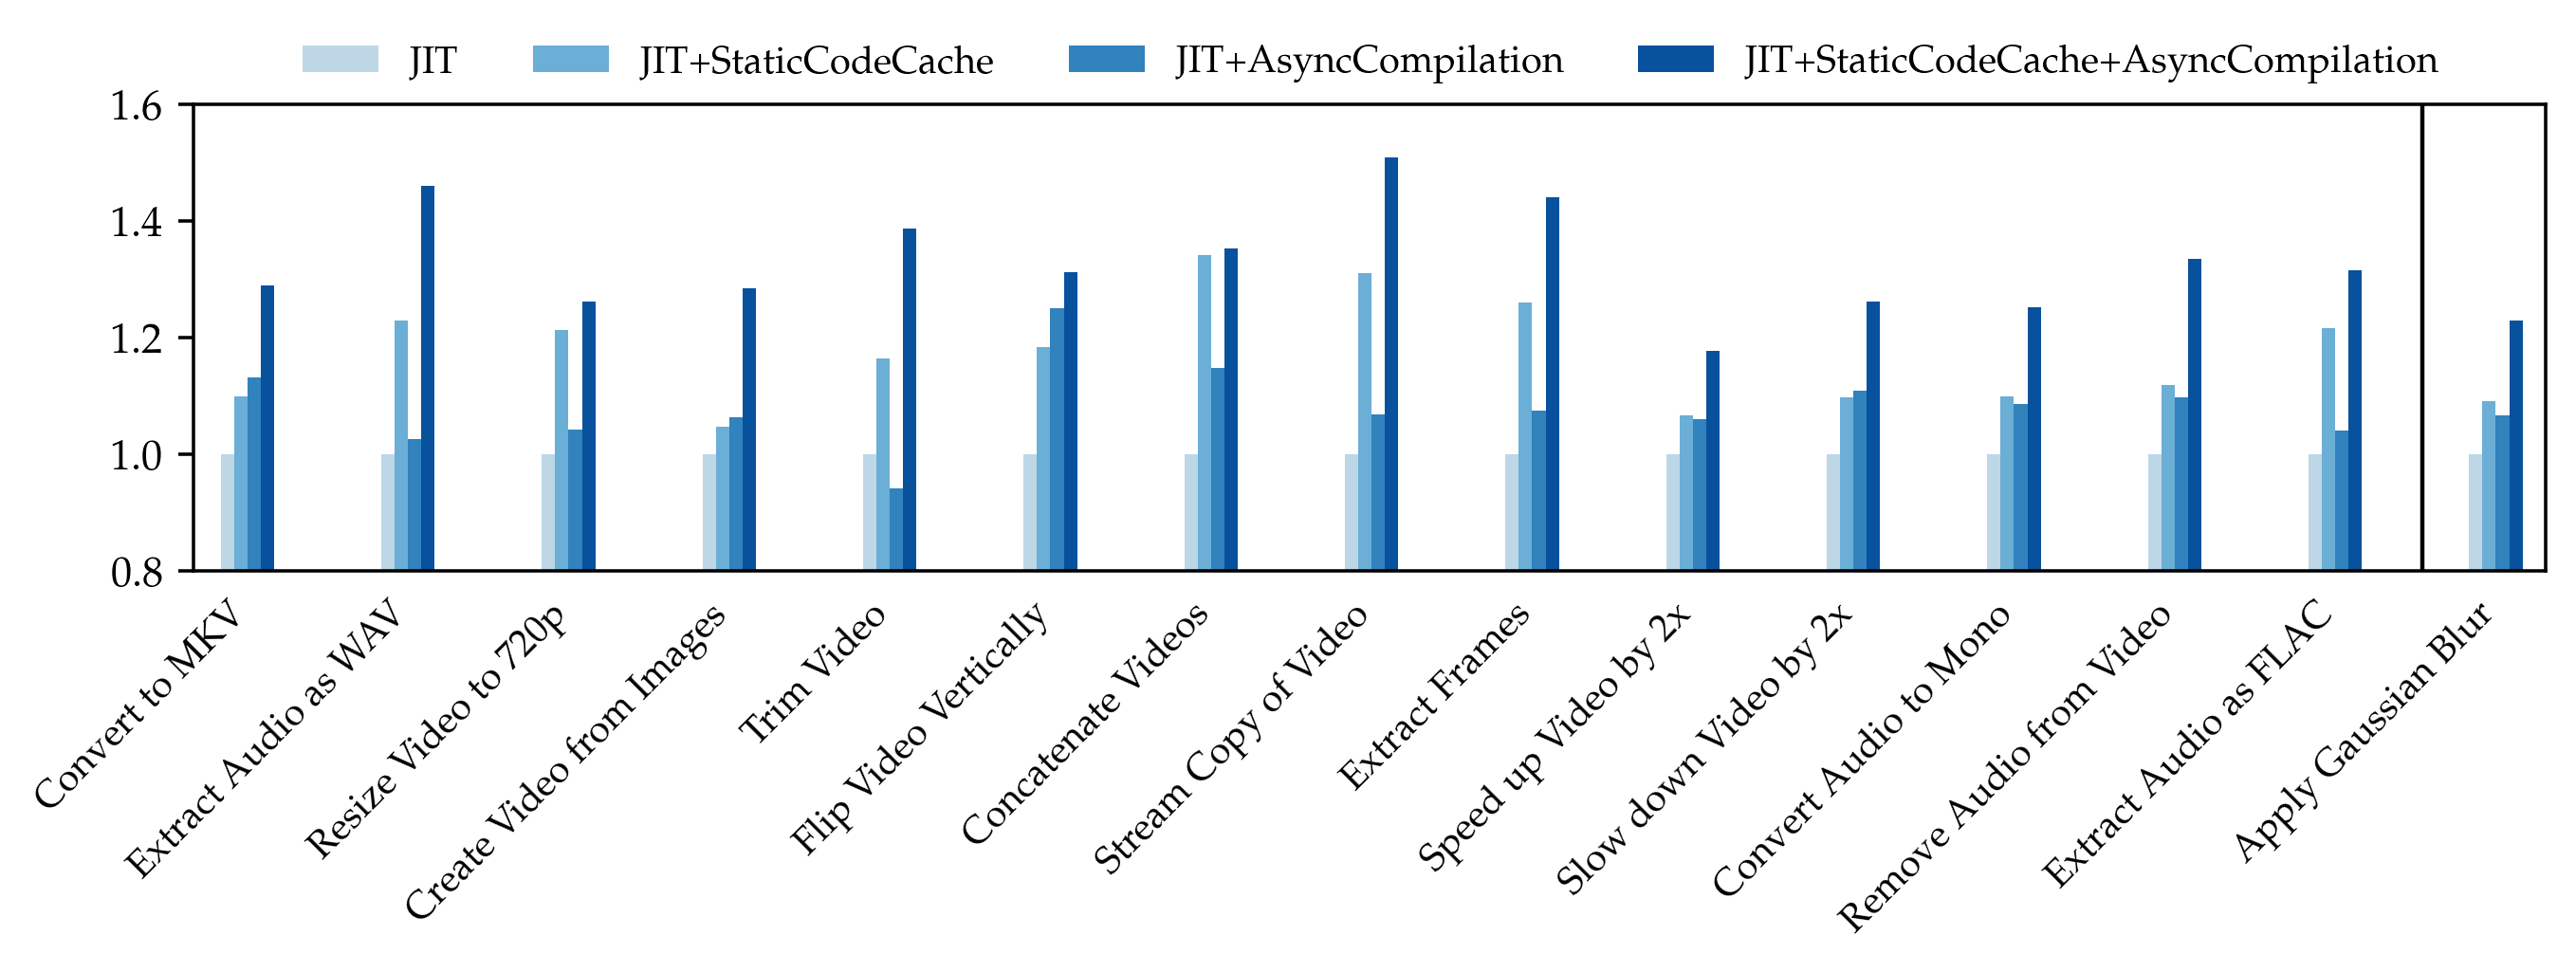

In [70]:
data = """
Convert to MKV, 114529, 104215, 101184, 88785, 
Extract Audio as WAV, 47776, 38853, 46531, 32739, 
Resize Video to 720p, 123803, 102039, 118693, 98068, 
Create Video from Images, 76428, 72932, 71895, 59511, 
Trim Video, 44846, 38537, 47597, 32342, 
Flip Video Vertically, 122456, 103478, 97939, 93314, 
Concatenate Videos, 50179, 37401, 43673, 37104, 
Stream Copy of Video, 47203, 36009, 44178, 31301, 
Extract Frames, 59384, 47137, 55212, 41246, 
Speed up Video by 2x, 112126, 105150, 105697, 95228, 
Slow down Video by 2x, 115020, 104741, 103668, 91143, 
Convert Audio to Mono, 114596, 104265, 105423, 91470, 
Remove Audio from Video, 105768, 94481, 96366, 79239, 
Extract Audio as FLAC, 54448, 44769, 52327, 41418,
Apply Gaussian Blur, 89174, 81719, 83589, 72490,
"""

lines = data.strip().split('\n')
lines = [line.split(',') for line in lines]
lines = [(line[0], int(line[1]), int(line[2]), int(line[3]), int(line[4])) for line in lines]
# line[0] is workload name
lines = [(line[0], [line[1], line[2], line[3], line[4]]) for line in lines]
lines
# make relative to the first item
for wl_idx, (name, vals) in enumerate(lines):
    baseline = vals[0]
    vals = [baseline / v for v in vals]
    lines[wl_idx] = (name, vals)
lines

import matplotlib.pyplot as plt
import bokeh.palettes

# plot as bars
# colors
colors = bokeh.palettes.Blues[len(strategies) + 1][:-1]
colors = colors[::-1]

# bars and spaces
bar_width = 2
strategy_bar_width = bar_width / len(strategies)

# figure
width = 10
height = 2
fig, ax = plt.subplots(figsize=(width, height), dpi=320)

# plot bars
wl_x = 0
xs = []
for wl_idx, (name, vals) in enumerate(lines):
    xs.append(wl_x)
    for s, strategy in enumerate(strategies):
        x = wl_x + s * strategy_bar_width
        value = vals[s]
        color = colors[s]
        ax.bar(x, value, width=strategy_bar_width, color=color, edgecolor='none', linewidth=1)
    wl_x += len(strategies) + 2

# draw a vertical line before the last workload
ax.axvline(x=wl_x - 8, color='black', linewidth=1)

# x label is the workloads name line[0]
ax.set_xticks(xs, [name for name, _ in lines], rotation=45, fontsize=9, ha='right', rotation_mode='anchor', va='top',
              y=0.01)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # no ticks

# margin 0
plt.margins(x=0.01, y=0)

ax.set_ylim((.8, 1.6))

# legend
labels = ['JIT', 'JIT+StaticCodeCache', 'JIT+AsyncCompilation', 'JIT+StaticCodeCache+AsyncCompilation']
for s, label in enumerate(labels):
    ax.bar(0, 0, color=colors[s], label=label)
ax.legend(loc='upper center',
          bbox_to_anchor=(0.5, 1.2),
          ncol=len(labels),
          fontsize=9,
          frameon=False,
          edgecolor='black')

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import numpy as np


# convert to K, M, G, T
def human_readable_size(size, _):
    magnitude = 0
    while abs(size) >= 1000:
        magnitude += 1
        size //= 1000
    # add more suffixes if you need them
    return '%d%s' % (size, ['', 'K', 'M', 'G', 'T', 'P'][magnitude])


formatter = FuncFormatter(human_readable_size)

with open('./in/size_start_durations.txt', 'r') as f:
    size_start_durations = f.readlines()
i = 0
name_and_size_start_durations = []
while i < len(size_start_durations):
    name = size_start_durations[i].strip()
    i += 1
    tmp = []
    for j in range(3):
        tmp.append(eval(size_start_durations[i]))
        i += 1
    name_and_size_start_durations.append((name, tmp[1]))  # only jit
for wl_idx, (name, size_start_duration) in enumerate(name_and_size_start_durations):
    sizes = [size_start_duration[i][0] for i in range(len(size_start_duration))]  # bytes
    sizes = [size / 1_000 for size in sizes]  # KB
    starts = [size_start_duration[i][1] for i in range(len(size_start_duration))]  # ns
    durations = [size_start_duration[i][2] for i in range(len(size_start_duration))]  # ns

    starts = [start / 1_000_000_000 for start in starts]  # s
    durations = [duration / 1_000_000_000 for duration in durations]  # s

    # assert that the items are sorted by start
    for i in range(1, len(size_start_duration)):
        assert starts[i] > starts[i - 1]

    # remove the start of the first item from all start times
    start_offset = starts[0]
    for i in range(len(size_start_duration)):
        starts[i] -= start_offset

    # subplot with one row and two columns
    fig = plt.figure(layout="constrained", figsize=(8, 10), dpi=320)

    nrows = 6
    ncols = 6
    gs = GridSpec(nrows, ncols, figure=fig)
    # three subplots; 1) 2 rows, 1 column, 2) 1 row, 5 columns, 3) 1 row, 5 columns

    size_vs_compilation_time = fig.add_subplot(gs[:1, :2])  # 1st row, 1st column
    compilation_frequency = fig.add_subplot(gs[1:2, :2])  # 2nd row, 1st column
    timeline_vs_compilation_time = fig.add_subplot(gs[0, 2:])  # 1st row, 2nd to 6th column
    timeline_vs_function_index = fig.add_subplot(gs[1, 2:])  # 2nd row, 2nd to 6th column
    deficit_surplus = fig.add_subplot(gs[2, :])  # 3rd row, 2nd to 6th column
    deficit_surplus_wasmtime = fig.add_subplot(gs[3, :])  # 4rd row, 2nd to 6th column
    cumulative_deficit_surplus = fig.add_subplot(gs[4, :])  # 5th row, 2nd to 6th column
    cumulative_deficit_surplus_wasmtime = fig.add_subplot(gs[5, :])  # 6th row, 2nd to 6th column

    # plot the binary size vs compilation time
    size_vs_compilation_time.scatter(sizes, durations, s=3, c='red', alpha=0.9, linewidths=0.2, edgecolors='black')
    size_vs_compilation_time.set_ylabel('Compilation (s)')
    size_vs_compilation_time.set_xlabel('Binary Size (KB)')
    size_vs_compilation_time.grid(False)
    size_vs_compilation_time.margins(0.01)

    # historgram of frequency of compilation over timeline
    compilation_frequency.hist(starts, bins=100, color='blue', alpha=0.5)
    compilation_frequency.set_ylabel('Compilation Frequency')
    compilation_frequency.set_xlabel('Timeline (s)')
    compilation_frequency.grid(False)
    compilation_frequency.margins(0.01)

    # plot the start time vs compilation time
    max_duration = max(durations) * 1.1
    timeline_vs_compilation_time.scatter(starts, durations, s=3, c='red', alpha=0.5, linewidths=0.2,
                                         edgecolors='black')
    # showing the start and duration of each compilation in red
    for i in range(len(size_start_duration)):
        timeline_vs_compilation_time.plot([starts[i], starts[i] + durations[i]], [durations[i], durations[i]],
                                          c='red', linewidth=1,
                                          zorder=-100)
        timeline_vs_compilation_time.plot([starts[i] + durations[i], starts[i] + durations[i]], [0, durations[i]],
                                          c='gray', linewidth=0.1,
                                          linestyle='dashed')

    # showing execution timeline in green 
    for i in range(1, len(size_start_duration)):
        if starts[i] > starts[i - 1] + durations[i - 1]:
            timeline_vs_compilation_time.plot([starts[i - 1] + durations[i - 1], starts[i]],
                                              [max_duration, max_duration], c='green',
                                              linewidth=1)

    # draw a hirizontal line at max_duration * 1.05
    timeline_vs_compilation_time.axhline(y=max_duration * .95, color='gray', linestyle='dashed', linewidth=0.5)

    # set max y limit to max_duration * 1.1
    timeline_vs_compilation_time.set_ylim(-0.02 * max_duration, max_duration * 1.1)

    timeline_vs_compilation_time.set_ylabel('Compilation (s)')
    timeline_vs_compilation_time.set_xlabel('Timeline (s)')
    timeline_vs_compilation_time.grid(False)
    timeline_vs_compilation_time.margins(0.0)

    # plot compilation in red
    for i in range(len(size_start_duration)):
        timeline_vs_function_index.plot([starts[i], starts[i] + durations[i]], [i, i], c='red', linewidth=1,
                                        zorder=-100)

    # plot execution timeline in green 
    for i in range(1, len(size_start_duration)):
        if starts[i] > starts[i - 1] + durations[i - 1]:
            timeline_vs_function_index.plot([starts[i - 1] + durations[i - 1], starts[i]], [i - 1, i - 1], c='green',
                                            linewidth=1)

    # set format for y axis
    timeline_vs_function_index.yaxis.set_major_formatter(formatter)

    timeline_vs_function_index.set_ylabel('Functions')
    timeline_vs_function_index.set_xlabel('Timeline (s)')
    timeline_vs_function_index.grid(False)
    timeline_vs_function_index.margins(0.0)

    # deficit surplus
    idle_times = []
    for i in range(1, len(size_start_duration)):
        idle_times.append(starts[i] - (starts[i - 1] + durations[i - 1]))
    waiting_times = []
    for i in range(1, len(size_start_duration)):
        waiting_times.append(durations[i])
    assert len(idle_times) == len(waiting_times)

    deficit_surplus.plot(idle_times, c='blue', linewidth=1)
    deficit_surplus.plot(waiting_times, c='red', linewidth=1)
    deficit_surplus.set_ylabel('Time (s)')
    deficit_surplus.set_xlabel('Functions')
    deficit_surplus.grid(False)
    deficit_surplus.margins(0.0)
    deficit_surplus.set_yscale('log')
    deficit_surplus.set_title(
        'Compilation time for the nexts function (red) and the time it takes to nexts function get requested (blue)')

    cumulative_deficit_surplus.plot(np.cumsum(idle_times) - np.cumsum(waiting_times), c='purple', linewidth=1)
    cumulative_deficit_surplus.axhline(y=0, color='gray', linestyle='dashed', linewidth=0.5)
    cumulative_deficit_surplus.set_ylabel('Time (s)')
    cumulative_deficit_surplus.set_xlabel('Functions')
    cumulative_deficit_surplus.grid(False)
    cumulative_deficit_surplus.margins(0.0)
    # make y log
    # cumulative_deficit_surplus.set_yscale('log')
    # the title is the cumulative_deficit_surplus
    cumulative_deficit_surplus.set_title('Cumulative surplus')

    old_durations = durations[:]
    # reduce the duration by 10%
    for i in range(len(size_start_duration)):
        durations[i] = durations[i] * .1

    # reduce the start time of each item by 10% of the previous duration
    cum_savings = 0
    for i in range(1, len(size_start_duration)):
        cum_savings += (old_durations[i - 1] * .9)
        starts[i] -= cum_savings

    # deficit surplus
    idle_times = []
    for i in range(1, len(size_start_duration)):
        idle_times.append(starts[i] - (starts[i - 1] + durations[i - 1]))
    waiting_times = []
    for i in range(1, len(size_start_duration)):
        waiting_times.append(durations[i])
    assert len(idle_times) == len(waiting_times)

    deficit_surplus_wasmtime.plot(idle_times, c='blue', linewidth=1)
    deficit_surplus_wasmtime.plot(waiting_times, c='red', linewidth=1)
    deficit_surplus_wasmtime.set_ylabel('Time (s)')
    deficit_surplus_wasmtime.set_xlabel('Functions')
    deficit_surplus_wasmtime.grid(False)
    deficit_surplus_wasmtime.margins(0.0)
    deficit_surplus_wasmtime.set_yscale('log')
    deficit_surplus_wasmtime.set_title(
        'Compilation time for the nexts function (red) and the time it takes to nexts function get requested (blue) [Wasmtime]')

    cumulative_deficit_surplus_wasmtime.plot(np.cumsum(idle_times) - np.cumsum(waiting_times), c='purple', linewidth=1)
    cumulative_deficit_surplus_wasmtime.axhline(y=0, color='gray', linestyle='dashed', linewidth=0.5)
    cumulative_deficit_surplus_wasmtime.set_ylabel('Time (s)')
    cumulative_deficit_surplus_wasmtime.set_xlabel('Functions')
    cumulative_deficit_surplus_wasmtime.grid(False)
    cumulative_deficit_surplus_wasmtime.margins(0.0)
    # make y log
    # cumulative_deficit_surplus_wasmtime.set_yscale('log')
    # the title is the cumulative_deficit_surplus_wasmtime
    cumulative_deficit_surplus_wasmtime.set_title('Cumulative surplus [Wasmtime]')

    # whole plot title is name
    fig.suptitle(f'{name} ({len(size_start_duration)} compilations)')

    # plt.tight_layout()

    # also write to file as jpeg with name as filename but prefix with index 00, 01, ...
    plt.savefig(f'./out/{str(wl_idx).zfill(2)}_{name}.jpeg', format='jpeg', dpi=320, bbox_inches='tight',
                pad_inches=0.1)

    plt.show()
    # break